<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Diabetes_Risk_Prediction_(_Ensembling_%5B_BaggingClassifier_%26_RandomForestClassifier%5D_Technique_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diabetes Risk Prediction**

## **Context:**
Diabetes is one of the most frequent diseases worldwide and the number of diabetic patients is growing over the years. The main cause of diabetes remains unknown, yet scientists believe that both genetic factors and environmental lifestyle play a major role in diabetes.

Individuals with diabetes face a risk of developing some secondary health issues such as heart diseases and nerve damage. Thus, early detection and treatment of diabetes can prevent complications and assist in reducing the risk of severe health problems. Even though it's incurable, it can be managed by treatment and medication.

Researchers at the Bio-Solutions lab want to get a better understanding of this disease among women and are planning to use machine learning models that will help them to identify patients who are at risk of diabetes.

You as a data scientist at Bio-Solutions have to build a classification model using a dataset collected by the "National Institute of Diabetes and Digestive and Kidney Diseases" consisting of several attributes that would help to identify whether a person is at risk of diabetes or not.

# **Objective:**
To build a model to predict whether an individual is at risk of diabetes or not.



## **Data Description:**
* **Pregnancies:** Number of times pregnant
* **Glucose:** Plasma glucose concentration over 2 hours in an oral glucose tolerance test
* **BloodPressure:** Diastolic blood pressure (mm Hg)
* **SkinThickness:** Triceps skinfold thickness (mm)
* **Insulin:** 2-Hour serum insulin (mu U/ml)
* **BMI:** Body mass index (weight in kg/(height in m)^2)
* **Pedigree:** Diabetes pedigree function - A function that scores likelihood of diabetes based on family history.
* **Age:** Age in years
* **Class:** Class variable (0: the person is not diabetic or 1: the person is diabetic)

In [279]:
# Importing all the libraries
# to load data
import pandas as pd
import numpy as np
import math
# to visualize data
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.5f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# to split data into training & testing
from sklearn.model_selection import train_test_split, cross_val_score

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree


# to tune different models
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# to perform statistical analysis
import scipy.stats as stats

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report
)

# displaying max column
pd.set_option('display.max_columns', None)

In [280]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [281]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/pima-indians-diabetes.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [282]:
# mkaing data copy from original dataset
df = data.copy()

In [283]:
# checking the data shape
rows, columns = df.shape
print(f"Total Columns : {columns} & Total rows : {rows}")

Total Columns : 9 & Total rows : 768


In [284]:
# checking the table by head & tail
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148,72,35,0,33.60000,0.62700,50,1
1,1,85,66,29,0,26.60000,0.35100,31,0
2,8,183,64,0,0,23.30000,0.67200,32,1
3,1,89,66,23,94,28.10000,0.16700,21,0
4,0,137,40,35,168,43.10000,2.28800,33,1


In [285]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
763,10,101,76,48,180,32.90000,0.17100,63,0
764,2,122,70,27,0,36.80000,0.34000,27,0
765,5,121,72,23,112,26.20000,0.24500,30,0
766,1,126,60,0,0,30.10000,0.34900,47,1
767,1,93,70,31,0,30.40000,0.31500,23,0


In [286]:
# checking the table information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Class          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


* There are total 9 rows, with 768 rows.
* no null values are present.
* all columns are numerical

In [287]:
# checking the duplicasy in data
df.duplicated().sum()

np.int64(0)

There is no duplicate rows are present in data.

In [288]:
# null values checking
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
Pedigree,0
Age,0
Class,0


There is no NULL values are present

In [289]:
# checking the data discription
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00000,3.84505,3.36958,0.00000,1.00000,3.00000,6.00000,17.00000
Glucose,768.00000,120.89453,31.97262,0.00000,99.00000,117.00000,140.25000,199.00000
BloodPressure,768.00000,69.10547,19.35581,0.00000,62.00000,72.00000,80.00000,122.00000
SkinThickness,768.00000,20.53646,15.95222,0.00000,0.00000,23.00000,32.00000,99.00000
Insulin,768.00000,79.79948,115.24400,0.00000,0.00000,30.50000,127.25000,846.00000
BMI,768.00000,31.99258,7.88416,0.00000,27.30000,32.00000,36.60000,67.10000
Pedigree,768.00000,0.47188,0.33133,0.07800,0.24375,0.37250,0.62625,2.42000
Age,768.00000,33.24089,11.76023,21.00000,24.00000,29.00000,41.00000,81.00000
Class,768.00000,0.34896,0.47695,0.00000,0.00000,0.00000,1.00000,1.00000


Here, in  Glucose, BloodPressure, SkinThickness, Insulin, BMI this column has 0 value as a minimum. But logically this attributes never been 0.

* So, we need to replace this value by median.

Why Median :
* This column has numerical datatype.
* if we relapce this values by max might be out will get biased. min values are already 0.
* Very important there is no any categorical column, where we can make the group by & fill the value based on group by condtion.
* So, replacin the value by median is correct way here.

In [290]:
# replacing the 0 value by median

data.loc[data.Glucose == 0, 'Glucose'] = data.Glucose.median()
data.loc[data.BloodPressure == 0, 'BloodPressure'] = data.BloodPressure.median()
data.loc[data.SkinThickness == 0, 'SkinThickness'] = data.SkinThickness.median()
data.loc[data.Insulin == 0, 'Insulin'] = data.Insulin.median()
data.loc[data.BMI == 0, 'BMI'] = data.BMI.median()

All Zero values has been replaced by median

In [291]:
# checking the data bifurcation on target column
print(df['Class'].value_counts(normalize=True))

Class
0   0.65104
1   0.34896
Name: proportion, dtype: float64


As per the data, 65% persons not Diabetes. 34% persons has Diabetes.

**EDA**

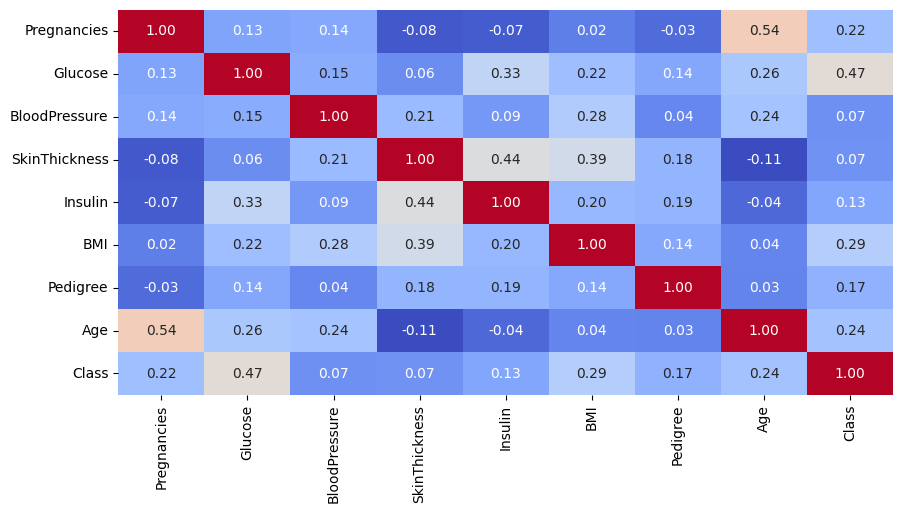

In [292]:
# checking the correlation in features
plt.figure(figsize = (10,5))
sns.heatmap(df.corr(), annot= True, cbar = False, fmt='0.2f', cmap = 'coolwarm')
plt.show()

* Glucose is high positive correlation with class attributes. Mens High glucose indicate likely hood chance of Diabetes As per the data.
* pregnancies, BMI, Age, Pedigree is moderate correlated with class atrribute. may be this are influences the chances of diabetes.

### **Data Modeling**

In [293]:
# spliting the data into base & target
X = df.iloc[:, :-1]
y = df.iloc[:,[ -1]]

In [294]:
# splitting the data for train & test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 1
)

In [295]:
# checking the splitted data % for test
print(f"% of data for train : {y_train.value_counts(normalize=True)}\n")
print(f"% of data for test : {y_test.value_counts(normalize=True)}")


% of data for train : Class
0       0.65922
1       0.34078
Name: proportion, dtype: float64

% of data for test : Class
0       0.63203
1       0.36797
Name: proportion, dtype: float64


## **Model Building**

In [296]:
# confusion matrics function

try :
  # ploting a confusion matrics
  def plot_confusion_matrics(model, predictor, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictor)

    # Compute the confusion matrix compairing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    cm_df = pd.DataFrame({
        "True Negative" : TN,
        "False Positive" : FP,
        "False Negative" : FN,
        "True Positive" : TP
    }, index = [0]).reset_index(drop=True)

    # create a labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format( item / cm.flatten().sum()) for item in cm.flatten()]
        ]
    ).reshape(2, 2)

    plt.figure(figsize = (4,3))

    sns.heatmap(cm, annot = labels, cmap = 'Spectral', fmt = "")

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    return cm_df

  print("Function defined")
except Exception as e :
  print(f"Model Not defined {e}")

Function defined


In [297]:
def classification_report_matrics(model, predicator, target):
  # prediction variable
  pred = model.predict(predicator)

  # confusion matrics
  cm = confusion_matrix(target, pred)
  error_rate = (cm[1,0]+ cm[0,1]) / (cm[0,0] + cm[0,1] + cm[1,0] + cm[1,1])

  # evaluation matrics
  acc = accuracy_score(target, pred)
  prec = precision_score(target, pred)
  recal = recall_score(target, pred)
  f1 = f1_score(target, pred)

  # keeping all matrics in one single df
  evaluation_df = pd.DataFrame({
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : recal,
      "F1-Score" : f1,
      "Error Rate" : error_rate
  }, index = [0])

  return evaluation_df

## **Model evaluation criterion**

**The model can make wrong predictions as:**
  1) Predicting a person doesn't have diabetes and the person has diabetes.
  2) Predicting a person has diabetes, and the person doesn't have diabetes.

**Which case is more important?**
  * Predicting a person doesn't have diabetes, and the person has diabetes.

**Which metric to optimize?**
  * here in this cases we want to maximize the recall, the grater the recall higher the chance of minimize the False Negative, because if the model has predicts that a person as it risk of diabetes and in reality, that person dosen't have Diabetes then the person can go through further level of testing to confirm weather the person is actually at risk of diabetes, but if we predict the person is not at risk of diabetes but actually that person at risk of diabetes then the person will go undiagnosed and this would lead to further health problem.

### **Decision Tree (Default parameters)**

In [298]:
# defining the decision tree
dtree = DecisionTreeClassifier(random_state=1)

In [299]:
# fitting the train data into model
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,354,0,0,183


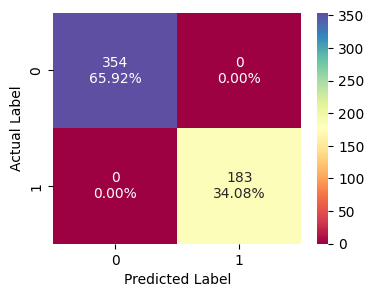

In [300]:
# plotting confusion matrics form fit data & model
plot_confusion_matrics(dtree, X_train, y_train)

In [301]:
# summary of model performance matrics on train data
simple_dtree_model_evaluation_train = classification_report_matrics(dtree, X_train, y_train)
simple_dtree_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,116,30,42,43


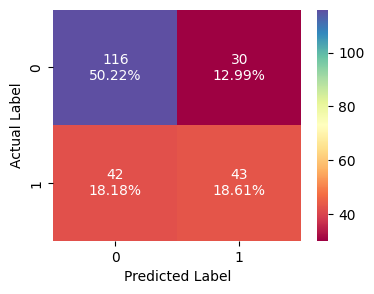

In [302]:
# plotting confusion matrics for test data
plot_confusion_matrics(dtree, X_test, y_test)

Our model identified 116 personal which is not actualy at risk, 30 persons whoes are actually not at risk but model predicted wrong, 42 persons are actually diabetes or at risk but model predicted as they don't at risk. This is very risky.

In [303]:
# summary of model performance on test data
simple_dtree_model_evaluation_test = classification_report_matrics(dtree, X_test, y_test)
simple_dtree_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.68831,0.58904,0.50588,0.54430,0.31169


* **As we can see model performance on default parameter, out model can performe well on seen data (train data) but performing poor on unseen data (test data). it is overfitting ( our model got overfitting )**

* **"The model is currently overfitting;" while it achieves 100% recall on training data, performance drops to 50% on the test set, indicating poor generalization.**





In [304]:
# plotting the text tree
feature_names = X.columns.tolist()
text_tree = tree.export_text(
    dtree,
    feature_names = feature_names,
    show_weights = True
)

print(text_tree)

|--- Glucose <= 129.50
|   |--- BMI <= 26.30
|   |   |--- BMI <= 9.10
|   |   |   |--- Glucose <= 114.50
|   |   |   |   |--- weights: [4.00, 0.00] class: 0
|   |   |   |--- Glucose >  114.50
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |--- BMI >  9.10
|   |   |   |--- Pedigree <= 0.67
|   |   |   |   |--- weights: [76.00, 0.00] class: 0
|   |   |   |--- Pedigree >  0.67
|   |   |   |   |--- Pedigree <= 0.71
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Pedigree >  0.71
|   |   |   |   |   |--- weights: [14.00, 0.00] class: 0
|   |--- BMI >  26.30
|   |   |--- Age <= 27.50
|   |   |   |--- BMI <= 45.40
|   |   |   |   |--- Pregnancies <= 7.00
|   |   |   |   |   |--- BloodPressure <= 12.00
|   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- BloodPressure >  12.00
|   |   |   |   |   |   |--- Pedigree <= 1.27
|   |   |   |   |   |   |   |--- BMI <= 30.95
|   |   |   |   |   |   |   |   |--- weights: [43.00, 

### **Feature Importance**

In [305]:
# feature importance
feature_importance = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : dtree.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)
print(feature_importance)

        Features  Importance
0        Glucose     0.29000
1            BMI     0.18000
2  BloodPressure     0.17000
3       Pedigree     0.12000
4            Age     0.12000
5    Pregnancies     0.05000
6  SkinThickness     0.05000
7        Insulin     0.03000


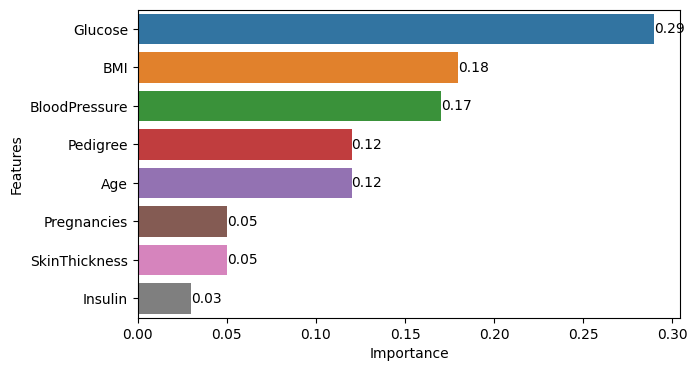

In [306]:
# graphical representation of Feature importance
plt.figure(figsize = (7, 4))
plot_1 = sns.barplot(feature_importance, x = 'Importance', y = 'Features', hue = 'Features')

for value in plot_1.containers :
  plot_1.bar_label(value)

plt.show()

**AS per the our simple Decision tree model, Glucose, BMI, BloodPressure attributes these top 3 are high attributes to predict Diabetes.**

### **Decision Tree ( Pre-Prun)**

in Pre-pruning if default decision tree get overfititng then,
use parameter to tune model -

**Small dataset (< 5k rows)**

    1) max_depth: 3 – 10
    2) min_samples_leaf: 5 – 50
    3) min_samples_split: 10 – 100

**Medium dataset (5k – 50k rows)**

    1) max_depth: 5 – 20
    2) min_samples_leaf: 1 – 20
    3) min_samples_split: 2 – 50

**Large dataset (> 50k rows)**

    1) max_depth: 10 – 30
    2) min_samples_leaf: 1 – 10
    3) min_samples_split: 2 – 20

In our current dataset rows < 5k so we following the rule 1

In [307]:
# using the grid search CV we can find best parameters for pre - pruned model
param_grid = {
    "criterion" : ['gini', 'entropy'],
    "max_depth" : np.arange(2, 10, 1),
    "min_samples_leaf" : np.arange(5, 50, 10),
    "min_samples_split" : np.arange(20, 100, 20)
}

In [308]:
# defining the GridSearchCV & finding the best parameters for pre-pruned Decision tree
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=1, class_weight = {0:0.35, 1:0.65}),
    param_grid= param_grid,
    cv = 5,  # cross validation
    scoring= 'recall',
    n_jobs= -1
)

# so basically we pass the parameter in param_grid, & aksing grid to find the beast parameters on recall score.

In [309]:
# so finally fitting the data into above defined grid_tree mdoel
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight={0: 0.35, 1: 0.65},
                                              random_state=1),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_samples_leaf': array([ 5, 15, 25, 35, 45]),
                         'min_samples_split': array([20, 40, 60, 80])},
             scoring='recall')

In [310]:
# checking the best paramerters
print(f"we got this best parameters from GridSearchCV : \n{grid_tree.best_params_}")

we got this best parameters from GridSearchCV : 
{'criterion': 'entropy', 'max_depth': np.int64(7), 'min_samples_leaf': np.int64(5), 'min_samples_split': np.int64(80)}


In [311]:
# reassigning the model name
dtree1 = grid_tree.best_estimator_

,True Negative,False Positive,False Negative,True Positive
0,295,59,56,127


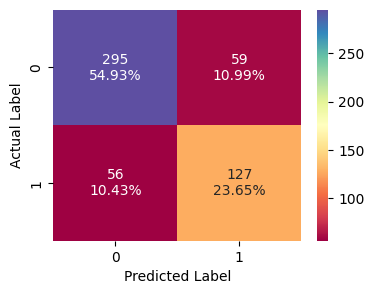

In [312]:
# plotting the confusion matrics for train dataset
plot_confusion_matrics(dtree1, X_train, y_train)

In [313]:
# summary of pre-pruned mdoel performance evaluation on trai data
preprun_dtree_model_evaluation_train = classification_report_matrics(dtree1, X_train, y_train)
preprun_dtree_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.78585,0.68280,0.69399,0.68835,0.21415


,True Negative,False Positive,False Negative,True Positive
0,120,26,26,59


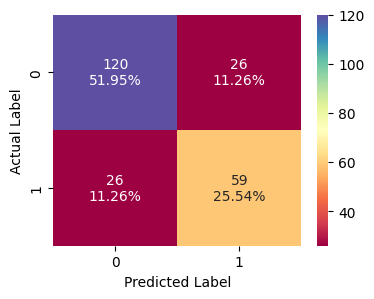

In [314]:
# plotting confusion matrics for test dataset
plot_confusion_matrics(dtree1, X_test, y_test)

In [315]:
# pre pruned model performance evaluation on test dataset
preprun_dtree_model_evaluation_test = classification_report_matrics(dtree1, X_test, y_test)
preprun_dtree_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.77489,0.69412,0.69412,0.69412,0.22511


* Our pre-pruned Decision tree model, on unseen data recall rate is 0.69 & on train data (seen data) 0.69. Accuracy rate on test data 0.77 & acuracy rate on train data 0.78.

* currently our model well genralized data patterns, but accuracy rate need to be improved with recall rate.

In [316]:
# plotting the text decision tree
feature_names = X.columns.tolist()
text_tree_1 = tree.export_text(
    dtree1,
    feature_names = feature_names,
    show_weights = True
    )

print(text_tree_1)

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- BMI <= 9.10
|   |   |   |--- weights: [1.40, 1.30] class: 0
|   |   |--- BMI >  9.10
|   |   |   |--- Pedigree <= 0.67
|   |   |   |   |--- weights: [26.25, 0.00] class: 0
|   |   |   |--- Pedigree >  0.67
|   |   |   |   |--- weights: [4.90, 0.65] class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 27.50
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- weights: [14.70, 0.65] class: 0
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- weights: [19.60, 8.45] class: 0
|   |   |--- Age >  27.50
|   |   |   |--- Glucose <= 89.50
|   |   |   |   |--- weights: [7.35, 0.65] class: 0
|   |   |   |--- Glucose >  89.50
|   |   |   |   |--- Pedigree <= 0.62
|   |   |   |   |   |--- weights: [17.85, 17.55] class: 0
|   |   |   |   |--- Pedigree >  0.62
|   |   |   |   |   |--- weights: [3.85, 14.95] class: 1
|--- Glucose >  127.50
|   |--- BMI <= 28.15
|   |   |--- weights: [11.20, 7.15] class: 0
|   |--- BMI >  28.15
|   |   |--- Glucose 

In [317]:
# summry of feature importance

feature_importance = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : dtree1.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance)

        Features  Importance
0        Glucose     0.48000
1            BMI     0.33000
2            Age     0.13000
3       Pedigree     0.06000
4  SkinThickness     0.00000
5  BloodPressure     0.00000
6    Pregnancies     0.00000
7        Insulin     0.00000


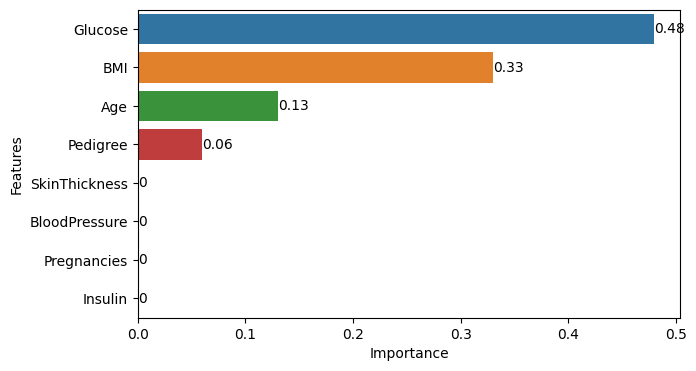

In [318]:
# plotting above summary in graphically
plt.figure(figsize = (7,4))
plot_2 = sns.barplot(feature_importance, x = "Importance", y = "Features", hue = "Features")

for value in plot_2.containers:
  plot_2.bar_label(value)

plt.show()

**According to Pre-pruned Decision Tree Model, Glucose, BMI & Age these 3 attributes are highly important to predict person as it in Risk or not.**

### **Decision Tree ( Post-Pruning )**

**here we dont go to use GridSearchCV**

In [319]:
# defining the model, ccp_alpha, impurities
clf = DecisionTreeClassifier(random_state= 1, class_weight = {0:0.35, 1:0.65})
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [320]:
pd.DataFrame(path).head()

,ccp_alphas,impurities
0,0.00000,-0.00000
1,0.00000,-0.00000
2,0.00000,-0.00000
3,0.00000,-0.00000
4,0.00000,-0.00000


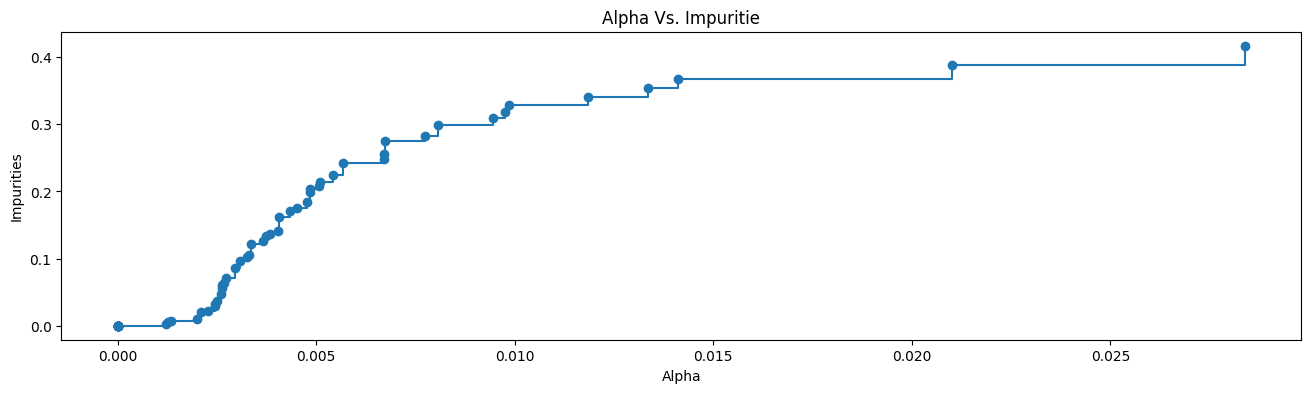

In [321]:
# plotting the graph of Alpha Vs. Impurities
fig, ax = plt.subplots(figsize = (16, 4))

ax.plot(ccp_alphas[:-1], impurities[:-1], marker = "o", drawstyle = "steps-post")
ax.set_xlabel("Alpha")
ax.set_ylabel("Impurities")
ax.set_title("Alpha Vs. Impuritie")
plt.show()

At alpha 0 then impurities also 0, so alpha increases impurities will also increase.

In [322]:
clfs = []

for ccp_alpha in ccp_alphas :
  clf = DecisionTreeClassifier(random_state =1, ccp_alpha=ccp_alpha)
  clf.fit(X_train, y_train)
  clfs.append(clf)

print(f"total number of nodes at last tree : {clfs[-1].tree_.node_count} with ccp_alpha {ccp_alphas[-1]}")

total number of nodes at last tree : 1 with ccp_alpha 0.08286643940544391


In [323]:
# Remove the last tree because it is overly pruned (often just a root node)
# and does not provide useful information for model evaluation
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

In [324]:
# now checking the aplha vs. Recall score to choose best alpha value

# on train data
train_recall = []

for clf in clfs :
  y_train_pred = clf.predict(X_train)
  recall_value = recall_score(y_train, y_train_pred)
  train_recall.append(recall_value)

In [325]:
# on test data
test_recall = []

for clf in clfs :
  y_test_pred = clf.predict(X_test)
  recall_value = recall_score(y_test, y_test_pred)
  test_recall.append(recall_value)

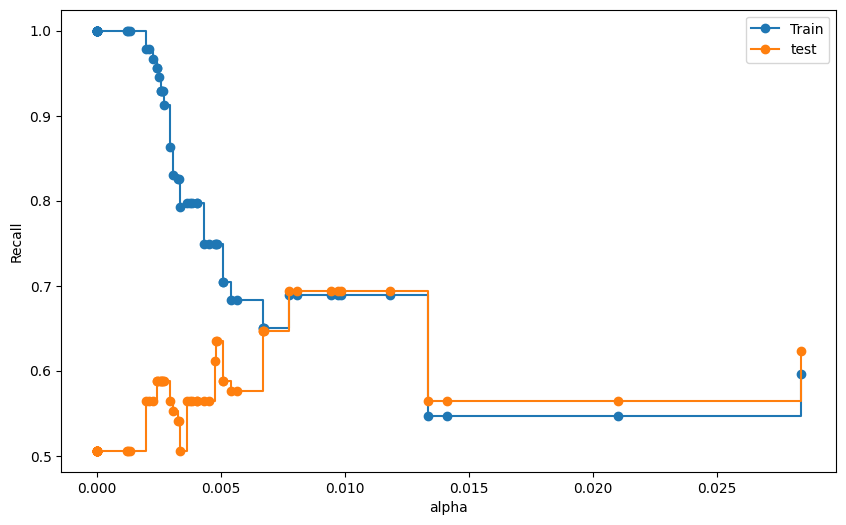

In [326]:
# plotting this train & test recall score Vs. Alpha
fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(ccp_alphas, train_recall, marker = "o", label = "Train", drawstyle = "steps-post")
ax.plot(ccp_alphas, test_recall, marker = "o", label = "test", drawstyle = "steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.legend()
plt.show()

In [327]:
# to find best alpha value
best_index = np.argmax(test_recall)
dtree2 = clfs[best_index]
dtree2

DecisionTreeClassifier(ccp_alpha=np.float64(0.0077509055922120595),
                       random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,294,60,57,126


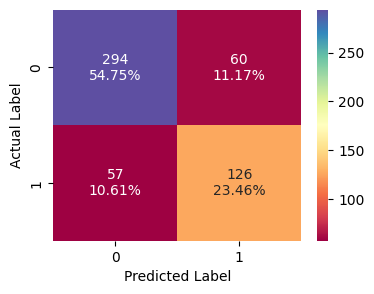

In [328]:
# plotting confusion matrics on dtree2
plot_confusion_matrics(dtree2, X_train, y_train)

In [329]:
# post-pruned model performance Evaluation on train dataset
postprun_dtree_model_evaluation_train = classification_report_matrics(dtree2, X_train, y_train)
postprun_dtree_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.78212,0.67742,0.68852,0.68293,0.21788


,True Negative,False Positive,False Negative,True Positive
0,119,27,26,59


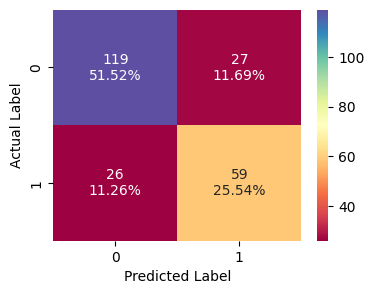

In [330]:
# plotting confusion matrics for test data from post-pruned model
plot_confusion_matrics(dtree2, X_test, y_test)

In [331]:
# summary of Post-pruned model performance evaluation on test data (unseen data)
postprun_dtree_model_evaluation_test = classification_report_matrics(dtree2, X_test, y_test)
postprun_dtree_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.77056,0.68605,0.69412,0.69006,0.22944


We can see clearly, after post-pruned our model accuracy on trian data is 0.78 & test data is 0.77. It is dropped 0.1.
* Recall score on train data around 0.68 & recall on test data around 0.69. Test Recall score increased significantly after hyperparameter tunning.
* the variation is not high but still accuracy score is less with recall rate so our model is in minimal overfitting. While recall rate is 0.69 slightly lower than accuracy.
* our model is well genralised & learned the patterns well.
* we want to boost the accuracy with recall rate, so will go for bagging & randomforest technics

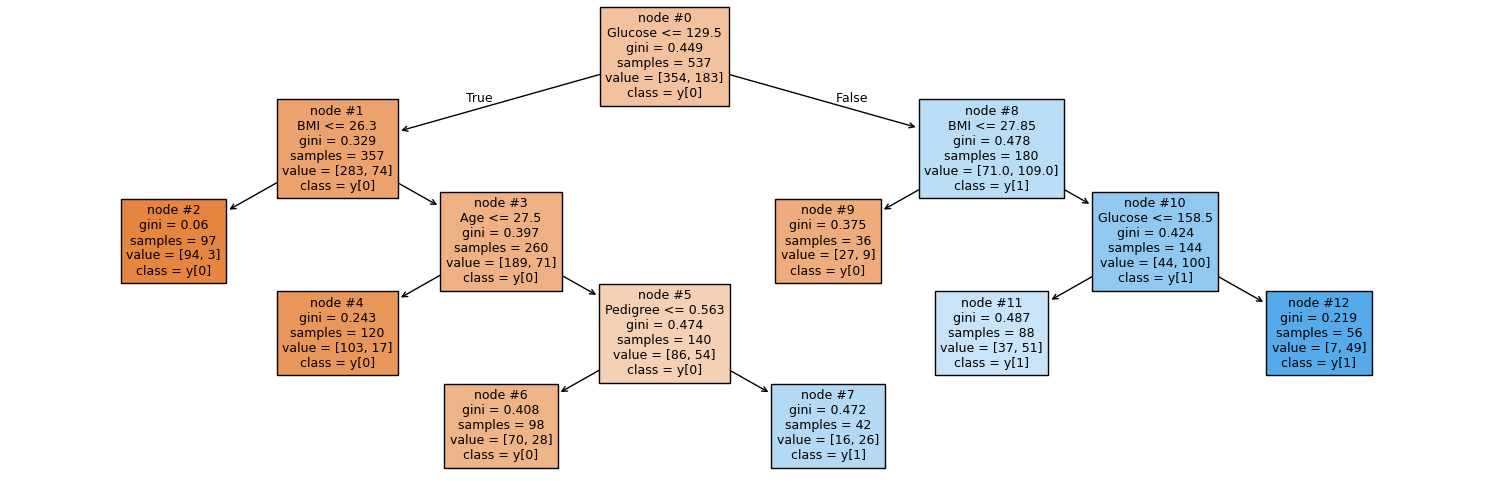

In [332]:
# plotting tree
feature_columns = X.columns.tolist()

plt.figure(figsize = (19, 6))
plot = tree.plot_tree(
    dtree2,
    feature_names = feature_columns,
    filled = True,
    node_ids = True,
    fontsize = 9,
    class_names = True
)
plt.show()

In [333]:
# plotting the text decision tree
feature_columns = X.columns.tolist()

text_tree_2 = tree.export_text(
    dtree2,
    feature_names = feature_columns,
    show_weights = True
)

print(text_tree_2)

|--- Glucose <= 129.50
|   |--- BMI <= 26.30
|   |   |--- weights: [94.00, 3.00] class: 0
|   |--- BMI >  26.30
|   |   |--- Age <= 27.50
|   |   |   |--- weights: [103.00, 17.00] class: 0
|   |   |--- Age >  27.50
|   |   |   |--- Pedigree <= 0.56
|   |   |   |   |--- weights: [70.00, 28.00] class: 0
|   |   |   |--- Pedigree >  0.56
|   |   |   |   |--- weights: [16.00, 26.00] class: 1
|--- Glucose >  129.50
|   |--- BMI <= 27.85
|   |   |--- weights: [27.00, 9.00] class: 0
|   |--- BMI >  27.85
|   |   |--- Glucose <= 158.50
|   |   |   |--- weights: [37.00, 51.00] class: 1
|   |   |--- Glucose >  158.50
|   |   |   |--- weights: [7.00, 49.00] class: 1



In [334]:
# feature importance

feature_importance_2 = pd.DataFrame({
    "Features" : X.columns,
    "Importance" : dtree2.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending= False).reset_index(drop=True)
print(feature_importance_2)

        Features  Importance
0        Glucose     0.56000
1            BMI     0.25000
2            Age     0.10000
3       Pedigree     0.08000
4  SkinThickness     0.00000
5  BloodPressure     0.00000
6    Pregnancies     0.00000
7        Insulin     0.00000


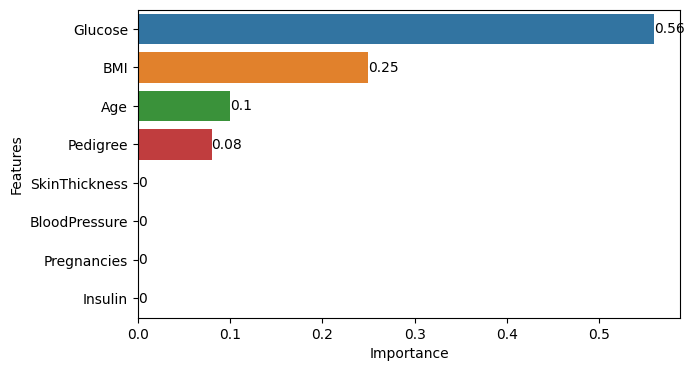

In [335]:
# graphical representation of feature importance
plt.figure(figsize = (7,4))
plot_3 = sns.barplot(feature_importance_2, x = "Importance", y = "Features", hue = "Features")

for value in plot_3.containers:
  plot_3.bar_label(value)

plt.show()

**Post-pruned Decision Tree model, Glucose & BMI both are high priority attributes to predict the person as it Risk or not**

### **Bagging Classifier ( Default parameter )**

In [336]:
# defining the Bagging classifier
bagging_classifier = BaggingClassifier(random_state=1)

In [337]:
# fittng the data into defined model
bagging_classifier.fit(X_train, y_train)

BaggingClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,352,2,9,174


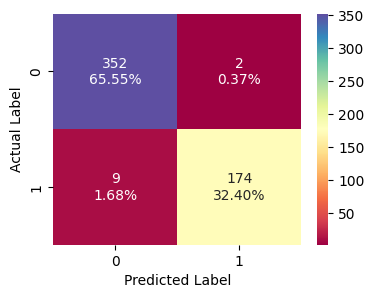

In [338]:
# plotting the confusion matrics for train data on bagging_classifier model
plot_confusion_matrics(bagging_classifier, X_train, y_train)

In [339]:
# Model performance evaluation matrics on bagging classifier trained model on train data
bagging_class_simple_model_evaluation_train = classification_report_matrics(bagging_classifier, X_train, y_train)
bagging_class_simple_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.97952,0.98864,0.95082,0.96936,0.02048


,True Negative,False Positive,False Negative,True Positive
0,129,17,41,44


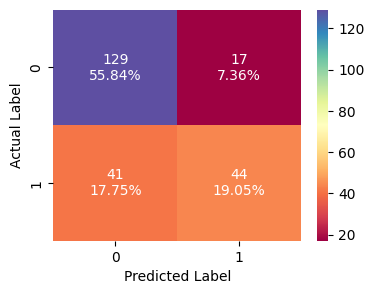

In [340]:
# plotting confusion matrics on test data on bagging_classifier model
plot_confusion_matrics(bagging_classifier, X_test, y_test)

In [341]:
# Model performance evaluation matrics on bagging classifier trained model on test data
bagging_class_simple_model_evaluation_test = classification_report_matrics(bagging_classifier, X_test, y_test)
bagging_class_simple_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.74892,0.72131,0.51765,0.60274,0.25108


**On simple Bagging Classifier, our model performaing well on train data with accuracy 0.97 & recall rate 0.95. But on unseen data (test data) our model performing poor with accuracy 0.74 & recall rate 0.51.**
* Indicating model is in **Overfitting**.

### **Bagging Classifier ( Tuned )**

**Using GridSearchCV we can tunned our bagging classifier**

In [342]:
# defining the range of parameter values in grid_param dict
param_grid = {
    "max_samples" : np.arange(0, 1, 0.2),
    "max_features" : np.arange(0, 1, 0.2),
    "n_estimators" : np.arange(10, 50, 10)
}

In [343]:
# defining the model using gridSearchcv for finding best parameters for model tunning
grid_dtree_1 = GridSearchCV(
    BaggingClassifier(random_state=1),
    param_grid = param_grid,
    scoring= 'recall',
    cv = 5
)

In [344]:
# fitting the data in above defined model
grid_dtree_1.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=BaggingClassifier(random_state=1),
             param_grid={'max_features': array([0. , 0.2, 0.4, 0.6, 0.8]),
                         'max_samples': array([0. , 0.2, 0.4, 0.6, 0.8]),
                         'n_estimators': array([10, 20, 30, 40])},
             scoring='recall')

In [345]:
# print the best parameters we got from gridSearch CV
print(grid_dtree_1.best_params_)

{'max_features': np.float64(0.8), 'max_samples': np.float64(0.8), 'n_estimators': np.int64(40)}


In [346]:
# best estimatoer
print(grid_dtree_1.best_estimator_)

BaggingClassifier(max_features=np.float64(0.8), max_samples=np.float64(0.8),
                  n_estimators=np.int64(40), random_state=1)


In [347]:
# re-assigning the mode name from gridsearchCv best estimator
bagging_classifier_dtree3 = grid_dtree_1.best_estimator_

,True Negative,False Positive,False Negative,True Positive
0,354,0,4,179


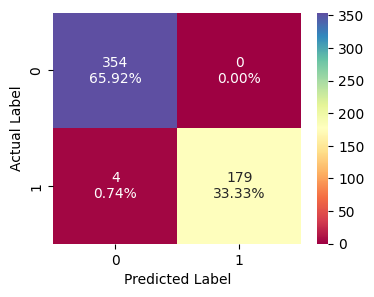

In [348]:
# plotting the confusion matrics on bagging_classifier_dtree3 model for train data
plot_confusion_matrics(bagging_classifier_dtree3, X_train, y_train)

In [349]:
# summary of model performance evaluation on train data
bagging_class_tunned_model_evaluation_train = classification_report_matrics(bagging_classifier_dtree3, X_train, y_train)
bagging_class_tunned_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.99255,1.00000,0.97814,0.98895,0.00745


,True Negative,False Positive,False Negative,True Positive
0,132,14,35,50


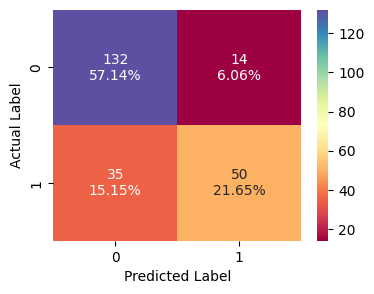

In [350]:
# plotting the confusion matrics on test data for bagging_classifier_dtree3
plot_confusion_matrics(bagging_classifier_dtree3, X_test, y_test)

In [351]:
# summary of model performance evaluation on test data
bagging_class_tunned_model_evaluation_test = classification_report_matrics(bagging_classifier_dtree3, X_test, y_test)
bagging_class_tunned_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.78788,0.78125,0.58824,0.67114,0.21212


After tunned BaggingClassifier model, accuracy rate on train is 0.99 & accuracy on test is 0.78 with recall rate on train is 0.97 & recall rate on test is 0.58.
* Model has memorized the training set but is struggling to handle new, unseen patterns.


**Still we haven't got that much of accuracy rate, so we going to use random forest another ensemble technique.**

### **Random Forest ( default parameter )**

In [352]:
# defining a model ( Random Forest Classifier )
random_forest_classifier = RandomForestClassifier(random_state = 1)

In [353]:
# fitting the data on model above
random_forest_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,354,0,0,183


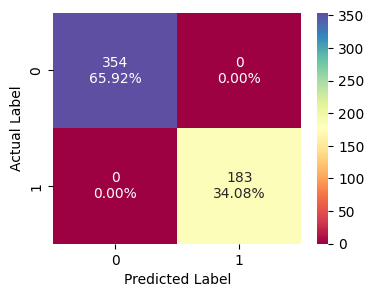

In [354]:
# plotting a confusion matrics on "random_forest_classifier" model.
plot_confusion_matrics(random_forest_classifier, X_train, y_train)

In [355]:
# summar of Model performance evaluation on train data for "random_forest_classifier" this model
randomforest_class_simple_model_evaluation_train = classification_report_matrics(random_forest_classifier, X_train, y_train)
randomforest_class_simple_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,131,15,34,51


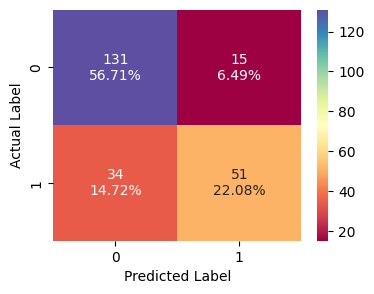

In [356]:
# plotting a confusion matrics on "random_forest_classifier" model on test data.
plot_confusion_matrics(random_forest_classifier, X_test, y_test)

In [357]:
# summar of Model performance evaluation on test data for "random_forest_classifier" this model
randomforest_class_simple_model_evaluation_test = classification_report_matrics(random_forest_classifier, X_test, y_test)
randomforest_class_simple_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.78788,0.77273,0.60000,0.67550,0.21212


After using random forest Classifier, our model is well perform on train data with 100% accuracy & 100% recall.
But model poor performing on unseen data (test data). Accuracy rate is 78% & recall rate is 67%.
- Model is overfititng.

### **Random Forest ( Tunned )**

we find best parameters for tunning Random forest, Using GridSearchCV method

In [358]:
# param_grid = {
#    "criterion" : ['gini', 'entropy'],
#    "max_depth" : np.arange(2,10,2),
#    "min_samples_split" : np.arange(10, 50, 10),
#    "min_samples_leaf" : np.arange(2,20, 3),
#    "max_features" : np.arange(0, 1, 0.2),
#    "n_estimators" : np.arange(60, 160, 20),
#    "min_impurity_decrease" : np.arange(0, 1, 0.04)
# }

# above parameters takiing too much time becasue hue parameters with huge range so we avoid to use above parameter grid

param_grid = {
   "criterion" : ['gini', 'entropy'],
   "max_depth" : [4, 6, 8],
   "min_samples_split" : [10, 20, 30],
   "min_samples_leaf" : [2, 5, 10],
   "max_features" : ['sqrt', 'log2'],
   "n_estimators" : [100, 120],
   "min_impurity_decrease" : [0.001, 0.003, 0.004, 0.01 ]
}

In [359]:
grid_dtree4 = GridSearchCV(
  RandomForestClassifier(random_state = 1, class_weight = {0:0.35, 1:0.65}),
  param_grid = param_grid,
  scoring = 'recall',
  cv = 5
)

In [360]:
# fitting the data into above trained model
grid_dtree4.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight={0: 0.35, 1: 0.65},
                                              random_state=1),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 6, 8],
                         'max_features': ['sqrt', 'log2'],
                         'min_impurity_decrease': [0.001, 0.003, 0.004, 0.01],
                         'min_samples_leaf': [2, 5, 10],
                         'min_samples_split': [10, 20, 30],
                         'n_estimators': [100, 120]},
             scoring='recall')

In [361]:
# printing the best parameters we got from GridSearchCV
print(grid_dtree4.best_params_)

{'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_impurity_decrease': 0.004, 'min_samples_leaf': 5, 'min_samples_split': 30, 'n_estimators': 100}


In [362]:
# checking the Best estimators from GridSearchCV
print(grid_dtree4.best_estimator_)

RandomForestClassifier(class_weight={0: 0.35, 1: 0.65}, criterion='entropy',
                       max_depth=4, min_impurity_decrease=0.004,
                       min_samples_leaf=5, min_samples_split=30,
                       random_state=1)


In [379]:
# reassigning the model name
randomforest_classifier_dtree4 = grid_dtree4.best_estimator_

,True Negative,False Positive,False Negative,True Positive
0,289,65,33,150


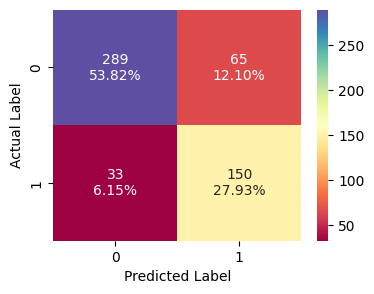

In [380]:
# plotting the confusion matrics on train data
plot_confusion_matrics(randomforest_classifier_dtree4, X_train, y_train)

In [381]:
# summary on model performance on train data
randomforest_class_tunned_model_evaluation_train = classification_report_matrics(randomforest_classifier_dtree4, X_train, y_train)
randomforest_class_tunned_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.81750,0.69767,0.81967,0.75377,0.18250


,True Negative,False Positive,False Negative,True Positive
0,124,22,18,67


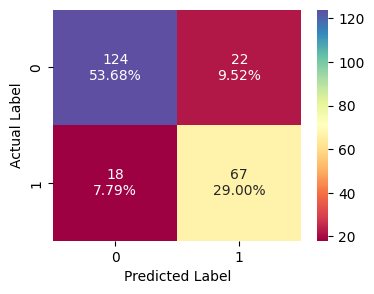

In [382]:
# plotting the confusion matrics on test data
plot_confusion_matrics(randomforest_classifier_dtree4, X_test, y_test)

In [383]:
# summary on model performance on test data
randomforest_class_tunned_model_evaluation_test = classification_report_matrics(randomforest_classifier_dtree4, X_test, y_test)
randomforest_class_tunned_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.82684,0.75281,0.78824,0.77011,0.17316


After tunning the Random Forest, our model is well performance on Train & Test data.
- Accuracy rate on train model 0.81 & 0.82 on test data with recall rate on train 0.81 & 0.78 on test data.
- It is indicating, in term of accuracy our test is on high & recall rate is 0.78 in test. Not huge gap.

### **Compairing all the models**

In [384]:
model_train_comp_df = pd.concat(
    [
      simple_dtree_model_evaluation_train.T,
      preprun_dtree_model_evaluation_train.T,
      postprun_dtree_model_evaluation_train.T,
      bagging_class_simple_model_evaluation_train.T,
      bagging_class_tunned_model_evaluation_train.T,
      randomforest_class_simple_model_evaluation_train.T,
      randomforest_class_tunned_model_evaluation_train.T
    ], axis = 1,
)

model_train_comp_df.columns = [
    "Simple Decision Tree",
    "Pre-pruned Decision Tree",
    "Post-pruned Decision Tree",
    "Bagging Classifier (Simaple)",
    "Bagging Classifier (Tunned)",
    "Random Forest Classifier (Simaple)",
    "Random Forest Classifier (Tunned)"
]

model_train_comp_df

,Simple Decision Tree,Pre-pruned Decision Tree,Post-pruned Decision Tree,Bagging Classifier (Simaple),Bagging Classifier (Tunned),Random Forest Classifier (Simaple),Random Forest Classifier (Tunned)
Accuracy,1.00000,0.78585,0.78212,0.97952,0.99255,1.00000,0.81750
Precision,1.00000,0.68280,0.67742,0.98864,1.00000,1.00000,0.69767
Recall,1.00000,0.69399,0.68852,0.95082,0.97814,1.00000,0.81967
F1-Score,1.00000,0.68835,0.68293,0.96936,0.98895,1.00000,0.75377
Error Rate,0.00000,0.21415,0.21788,0.02048,0.00745,0.00000,0.18250


In [389]:
model_test_comp_df = pd.concat(
    [
      simple_dtree_model_evaluation_test.T,
      preprun_dtree_model_evaluation_test.T,
      postprun_dtree_model_evaluation_test.T,
      bagging_class_simple_model_evaluation_test.T,
      bagging_class_tunned_model_evaluation_test.T,
      randomforest_class_simple_model_evaluation_test.T,
      randomforest_class_tunned_model_evaluation_test.T
    ], axis = 1,
)

model_test_comp_df.columns = [
    "Simple Decision Tree",
    "Pre-pruned Decision Tree",
    "Post-pruned Decision Tree",
    "Bagging Classifier (Simaple)",
    "Bagging Classifier (Tunned)",
    "Random Forest Classifier (Simaple)",
    "Random Forest Classifier (Tunned)"
]

model_test_comp_df

,Simple Decision Tree,Pre-pruned Decision Tree,Post-pruned Decision Tree,Bagging Classifier (Simaple),Bagging Classifier (Tunned),Random Forest Classifier (Simaple),Random Forest Classifier (Tunned)
Accuracy,0.68831,0.77489,0.77056,0.74892,0.78788,0.78788,0.82684
Precision,0.58904,0.69412,0.68605,0.72131,0.78125,0.77273,0.75281
Recall,0.50588,0.69412,0.69412,0.51765,0.58824,0.60000,0.78824
F1-Score,0.54430,0.69412,0.69006,0.60274,0.67114,0.67550,0.77011
Error Rate,0.31169,0.22511,0.22944,0.25108,0.21212,0.21212,0.17316


**From above summary, we decisded to use Random Forest Classifier (Tunned) model as a best model.**

-> **Accuracy rate is 82% & recall rate is 78%.**

giving genralized performance compaired with others on test.

### **Feature importance of tuned Random Forest Classifier**

In [395]:
# feature importance

feature_importances = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : randomforest_classifier_dtree4.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importances)

        Features  Importance
0        Glucose     0.32000
1            BMI     0.22000
2            Age     0.15000
3       Pedigree     0.09000
4    Pregnancies     0.07000
5        Insulin     0.07000
6  SkinThickness     0.04000
7  BloodPressure     0.04000


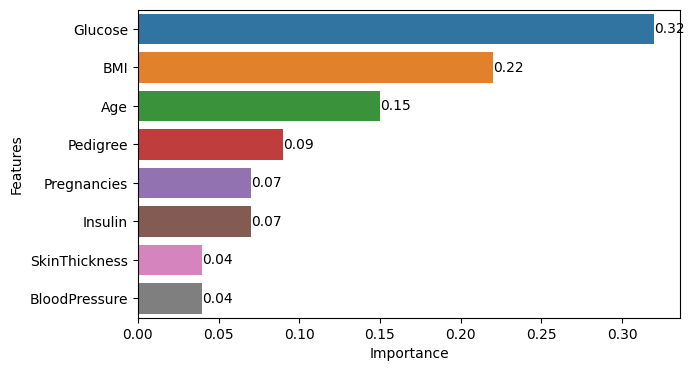

In [386]:
# graphical representation of feature importance
plt.figure(figsize = (7,4))
plot_5 = sns.barplot(feature_importances, x = "Importance", y = "Features", hue = "Features")

for value in plot_5.containers:
  plot_5.bar_label(value)

plt.show()

**According to our Best Model, Glucose, BMI, Age, pedigree this all are more important parameter to identify person whoes are at Risk or who are not at Risk.**